# Dataset analysis for Caltech101 and Enrico

This notebook keeps the code compact and focuses on a few paper-friendly views: Caltech101 summary statistics, then Enrico screenshots vs wireframes with UMAP-based similarity and overlap metrics.

In [1]:
!pip install -q umap-learn

import numpy as np
import seaborn as sns
from IPython.display import display
from torch.utils.data import ConcatDataset, DataLoader
from torchvision import datasets

from natural_images import (
    AugmentationWrapper, 
    make_caltech_base_transform, 
    stratified_three_way_split
)
from screen_images import (
    CustomEnricoDataset, 
    make_screen_base_transform
)
from dataset_analysis_utils import (
    extract_labels,
    class_count_frame,
    split_summary_frame,
    plot_class_count_histogram,
    show_sample_grid,
    numbered_table,
    dataset_to_matrix,
    project_with_umap,
    plot_umap,
    summarize_umap,
    print_umap_summary,
)
from training import (
    mean_and_std_for_normalization, 
    seed_everything
)


In [2]:
SEED = 317
seed_everything(seed=SEED)
sns.set_theme(style='whitegrid')

In [3]:
screen_base_transform = make_screen_base_transform(resize=(300, 200))
wireframe_base_transform = screen_base_transform

## Caltech101 summary

The goal here is to keep the stats compact but useful: split balance, class balance, a few sample images, and the original-train mean/std used for standardization.

100%|██████████| 137M/137M [00:02<00:00, 47.5MB/s]


Caltech101 total samples: 8677
Caltech101 classes: 101


,split,samples,share_%
0,train,6073,69.99
1,val,1302,15.01
2,test,1302,15.01


,train_class_counts
count,101.000000
mean,60.128713
std,82.824110
min,22.000000
25%,32.000000
50%,41.000000
75%,56.000000
max,560.000000


Most frequent training classes


,class_index,class_name,count
rank,,,
1,5,5,560
2,3,3,559
3,0,0,304
4,1,1,304
5,94,94,167
6,2,2,140
7,12,12,90
8,19,19,86
9,55,55,80


Least frequent training classes


,class_index,class_name,count
rank,,,
1,52,52,22
2,64,64,22
3,11,11,23
4,44,44,24
5,73,73,24
6,97,97,24
7,43,43,24
8,67,67,25
9,83,83,25


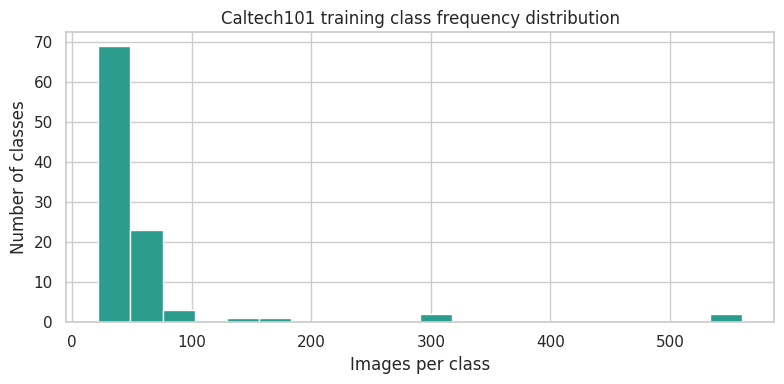

Caltech101 train samples


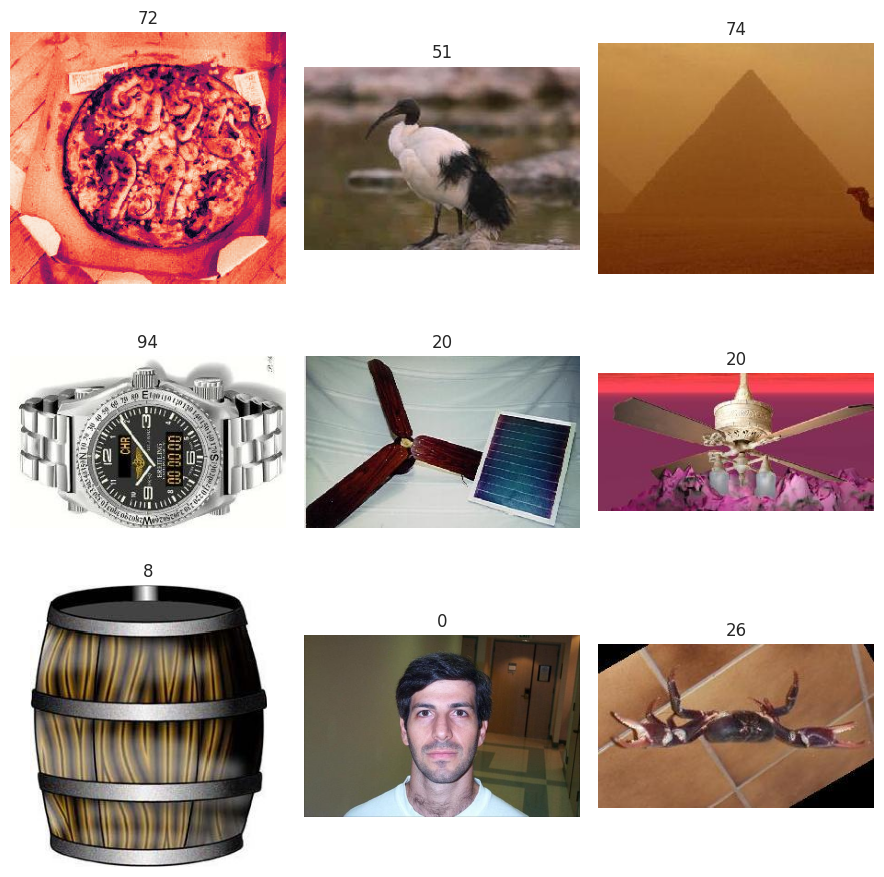

Caltech101 train mean: [0.546994 0.529921 0.501942]
Caltech101 train std: [0.313073 0.307583 0.320652]


In [4]:
caltech_dataset = datasets.Caltech101(root='./data', download=True)
caltech_train_raw, caltech_val_raw, caltech_test_raw = stratified_three_way_split(
    dataset=caltech_dataset,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=SEED,
)

caltech_labels = extract_labels(caltech_dataset)
caltech_class_names = [str(index) for index in sorted(np.unique(caltech_labels))]
caltech_train_counts = class_count_frame(caltech_train_raw, caltech_class_names)
caltech_split_counts = split_summary_frame(caltech_train_raw, caltech_val_raw, caltech_test_raw)

print(f'Caltech101 total samples: {len(caltech_dataset)}')
print(f'Caltech101 classes: {len(caltech_class_names)}')
display(caltech_split_counts)
display(caltech_train_counts['count'].describe().to_frame('train_class_counts'))
print('Most frequent training classes')
display(numbered_table(caltech_train_counts.sort_values('count', ascending=False).head(10)))
print('Least frequent training classes')
display(numbered_table(caltech_train_counts.sort_values('count', ascending=True).head(10)))
plot_class_count_histogram(caltech_train_counts['count'], 'Caltech101 training class frequency distribution')
show_sample_grid(caltech_train_raw, class_names=caltech_class_names, title='Caltech101 train samples', n_samples=9)

caltech_base_transform = make_caltech_base_transform(resize=(300, 200))
caltech_train_loader = DataLoader(
    AugmentationWrapper(caltech_train_raw, caltech_base_transform),
    batch_size=128,
    shuffle=False,
    num_workers=0,
)
caltech_mean, caltech_std = mean_and_std_for_normalization(caltech_train_loader)
print('Caltech101 train mean:', np.round(caltech_mean, 6))
print('Caltech101 train std:', np.round(caltech_std, 6))

## Enrico screenshots and wireframes

For UMAP, the notebook uses the raw split first, then the same pixel-level embedding pipeline for screenshots and wireframes so the two modalities stay comparable.

In [5]:
ENRICO_ROOT = '/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes'

screen_train_raw, screen_val_raw, screen_test_raw = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    seed=SEED,
    use_wireframes=False,
    transform=None,
    train_transform=None,
    eval_transform=None,
    augment_for_each=None,
    allowed_classes=None,
)
wire_train_raw, wire_val_raw, wire_test_raw = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    seed=SEED,
    use_wireframes=True,
    transform=None,
    train_transform=None,
    eval_transform=None,
    augment_for_each=None,
    allowed_classes=None,
)

screen_all = ConcatDataset([screen_train_raw, screen_val_raw, screen_test_raw])
wire_all = ConcatDataset([wire_train_raw, wire_val_raw, wire_test_raw])
screen_class_names = [name for name, index in sorted(screen_train_raw.class_to_idx.items(), key=lambda item: item[1])]
wire_class_names = [name for name, index in sorted(wire_train_raw.class_to_idx.items(), key=lambda item: item[1])]
screen_train_counts = class_count_frame(screen_train_raw, screen_class_names)
wire_train_counts = class_count_frame(wire_train_raw, wire_class_names)

print(f'Screenshot split sizes: {len(screen_train_raw)} / {len(screen_val_raw)} / {len(screen_test_raw)}')
print(f'Wireframe split sizes: {len(wire_train_raw)} / {len(wire_val_raw)} / {len(wire_test_raw)}')
display(split_summary_frame(screen_train_raw, screen_val_raw, screen_test_raw))
display(split_summary_frame(wire_train_raw, wire_val_raw, wire_test_raw))
display(screen_train_counts['count'].describe().to_frame('screenshots_class_counts'))
display(wire_train_counts['count'].describe().to_frame('wireframes_class_counts'))
print('Most frequent screenshot classes')
display(numbered_table(screen_train_counts.sort_values('count', ascending=False).head(10)))
print('Least frequent screenshot classes')
display(numbered_table(screen_train_counts.sort_values('count', ascending=True).head(10)))
print('Most frequent wireframe classes')
display(numbered_table(wire_train_counts.sort_values('count', ascending=False).head(10)))
print('Least frequent wireframe classes')
display(numbered_table(wire_train_counts.sort_values('count', ascending=True).head(10)))

Screenshot split sizes: 1020 / 219 / 219
Wireframe split sizes: 1020 / 219 / 219


,split,samples,share_%
0,train,1020,69.96
1,val,219,15.02
2,test,219,15.02


,split,samples,share_%
0,train,1020,69.96
1,val,219,15.02
2,test,219,15.02


,screenshots_class_counts
count,20.000000
mean,51.000000
std,45.531944
min,4.000000
25%,19.750000
50%,42.000000
75%,65.250000
max,185.000000


,wireframes_class_counts
count,20.000000
mean,51.000000
std,45.531944
min,4.000000
25%,19.750000
50%,42.000000
75%,65.250000
max,185.000000


...

,class_index,class_name,count
rank,,,
1,1,calculator,4
2,2,camera,6
3,9,maps,6
4,3,chat,8
5,4,editor,13
6,10,mediaplayer,22
7,16,search,25
8,18,terms,27
9,14,other,36


Most frequent wireframe classes


,class_index,class_name,count
rank,,,
1,7,list,185
2,19,tutorial,114
3,6,gallery,101
4,8,login,99
5,5,form,72
6,17,settings,63
7,11,menu,55
8,0,bare,53
9,12,modal,47


Least frequent wireframe classes


,class_index,class_name,count
rank,,,
1,1,calculator,4
2,2,camera,6
3,9,maps,6
4,3,chat,8
5,4,editor,13
6,10,mediaplayer,22
7,16,search,25
8,18,terms,27
9,14,other,36


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


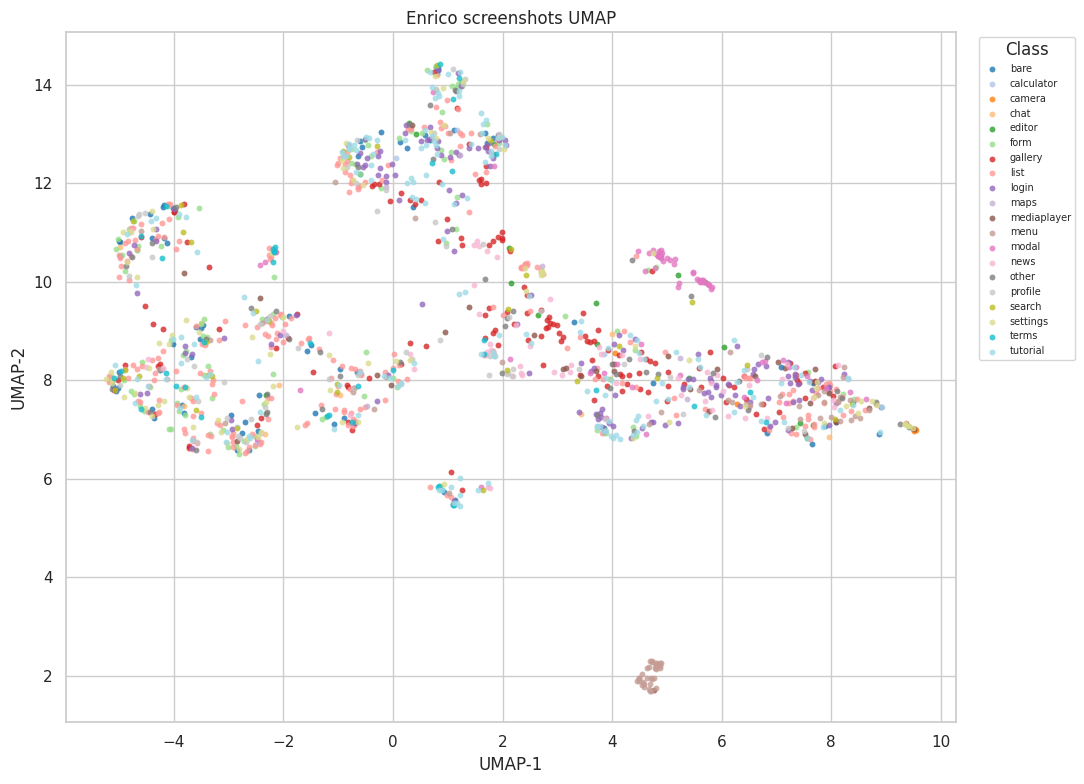

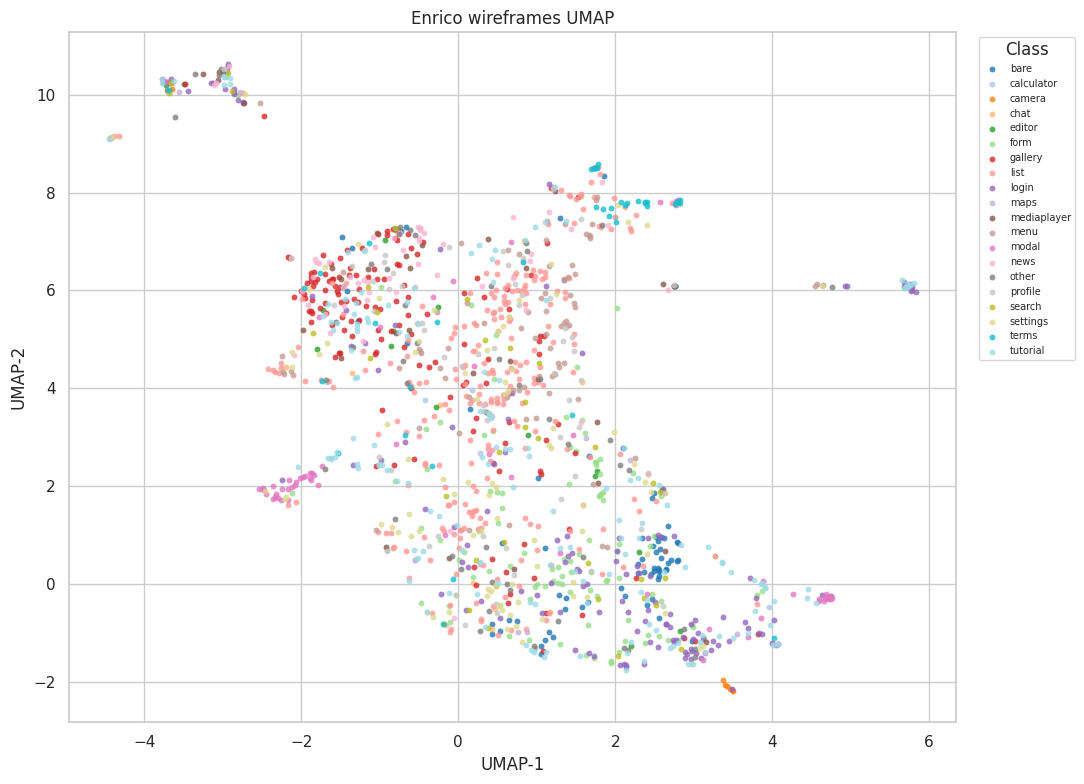


Screenshots UMAP summary
Per-class neighborhood purity


,purity@15
modal,0.518408
menu,0.476793
list,0.265409
camera,0.216667
gallery,0.210185
login,0.183452
tutorial,0.149693
news,0.108772
settings,0.100741
form,0.095793


Class-by-class overlap matrix


,bare,calculator,camera,chat,editor,form,gallery,list,login,maps,mediaplayer,menu,modal,news,other,profile,search,settings,terms,tutorial
bare,0.078,0.005,0.005,0.014,0.014,0.110,0.068,0.216,0.081,0.005,0.010,0.024,0.009,0.011,0.038,0.049,0.027,0.090,0.032,0.114
calculator,0.067,0.000,0.011,0.000,0.011,0.089,0.078,0.233,0.167,0.000,0.000,0.056,0.022,0.033,0.033,0.056,0.022,0.011,0.000,0.111
camera,0.050,0.008,0.217,0.000,0.000,0.000,0.033,0.058,0.033,0.000,0.033,0.042,0.017,0.042,0.125,0.008,0.008,0.258,0.000,0.067
chat,0.097,0.006,0.006,0.000,0.030,0.115,0.067,0.194,0.103,0.006,0.012,0.018,0.018,0.006,0.030,0.036,0.042,0.067,0.018,0.127
editor,0.044,0.004,0.004,0.015,0.026,0.059,0.152,0.211,0.078,0.000,0.037,0.011,0.107,0.033,0.033,0.033,0.015,0.037,0.007,0.093
form,0.083,0.003,0.001,0.009,0.012,0.096,0.054,0.222,0.094,0.004,0.010,0.017,0.025,0.010,0.036,0.049,0.025,0.082,0.030,0.137
gallery,0.035,0.004,0.003,0.006,0.018,0.042,0.210,0.143,0.101,0.007,0.021,0.022,0.033,0.075,0.046,0.045,0.023,0.038,0.023,0.105
list,0.060,0.004,0.002,0.008,0.010,0.081,0.074,0.265,0.071,0.011,0.017,0.030,0.020,0.025,0.034,0.044,0.030,0.090,0.038,0.086
login,0.042,0.008,0.002,0.006,0.011,0.077,0.101,0.137,0.183,0.009,0.026,0.036,0.031,0.042,0.030,0.043,0.017,0.037,0.017,0.146
maps,0.007,0.000,0.000,0.000,0.007,0.052,0.111,0.296,0.170,0.000,0.015,0.037,0.022,0.037,0.015,0.037,0.007,0.081,0.022,0.081


Class centroid distances in UMAP space


...

,bare,calculator,camera,chat,editor,form,gallery,list,login,maps,mediaplayer,menu,modal,news,other,profile,search,settings,terms,tutorial
bare,0.000,1.679,2.445,1.529,3.784,0.610,3.905,2.666,0.381,3.689,4.350,3.431,1.274,5.162,2.457,2.629,1.839,1.526,4.686,1.162
calculator,1.679,0.000,4.078,0.371,2.148,1.933,2.255,1.093,1.474,2.032,2.749,2.111,0.744,3.585,0.898,1.073,0.160,0.243,3.453,0.547
camera,2.445,4.078,0.000,3.849,6.215,2.176,6.330,5.107,2.768,6.109,6.792,5.850,3.496,7.606,4.897,5.071,4.237,3.888,7.053,3.595
chat,1.529,0.371,3.849,0.000,2.433,1.678,2.527,1.432,1.403,2.298,3.051,2.477,0.396,3.892,1.247,1.419,0.480,0.144,3.820,0.580
editor,3.784,2.148,6.215,2.433,0.000,4.081,0.167,1.129,3.509,0.215,0.636,1.216,2.826,1.475,1.336,1.175,1.992,2.361,2.063,2.623
form,0.610,1.933,2.176,1.678,4.081,0.000,4.186,3.003,0.972,3.960,4.679,3.878,1.321,5.509,2.796,2.973,2.089,1.727,5.172,1.506
gallery,3.905,2.255,6.330,2.527,0.167,4.186,0.000,1.266,3.639,0.231,0.609,1.374,2.916,1.423,1.470,1.314,2.098,2.461,2.155,2.744
list,2.666,1.093,5.107,1.432,1.129,3.003,1.266,0.000,2.382,1.073,1.685,1.123,1.826,2.508,0.210,0.057,0.955,1.329,2.445,1.514
login,0.381,1.474,2.768,1.403,3.509,0.972,3.639,2.382,0.000,3.429,4.056,3.085,1.240,4.854,2.173,2.340,1.627,1.366,4.322,0.928
maps,3.689,2.032,6.109,2.298,0.215,3.960,0.231,1.073,3.429,0.000,0.823,1.355,2.687,1.650,1.271,1.124,1.874,2.235,2.271,2.527


Most overlapping class pairs


,class_a,class_b,neighbor_overlap,centroid_distance
115,list,menu,0.204,1.123
24,calculator,list,0.198,1.093
105,gallery,news,0.174,1.423
134,login,tutorial,0.172,0.928
121,list,settings,0.167,1.329
57,chat,list,0.126,1.432
87,form,login,0.123,0.972
122,list,terms,0.123,2.445
119,list,profile,0.122,0.057
102,gallery,mediaplayer,0.109,0.609


Closest class centroids


,class_a,class_b,neighbor_overlap,centroid_distance
119,list,profile,0.122,0.057
67,chat,settings,0.058,0.144
33,calculator,search,0.007,0.160
71,editor,gallery,0.089,0.167
175,other,profile,0.049,0.178
118,list,other,0.084,0.210
74,editor,maps,0.017,0.215
101,gallery,maps,0.012,0.231
34,calculator,settings,0.017,0.243
20,calculator,chat,0.017,0.371


In [6]:
screen_features, screen_labels = dataset_to_matrix(screen_all, resize=(48, 48))
wire_features, wire_labels = dataset_to_matrix(wire_all, resize=(48, 48))

screen_coords = project_with_umap(screen_features)
wire_coords = project_with_umap(wire_features)

plot_umap(screen_coords, screen_labels, screen_class_names, 'Enrico screenshots UMAP', save_path='enrico_screenshots_umap.png')
plot_umap(wire_coords, wire_labels, wire_class_names, 'Enrico wireframes UMAP', save_path='enrico_wireframes_umap.png')

screen_summary = summarize_umap(screen_coords, screen_labels, screen_class_names, k=15)
wire_summary = summarize_umap(wire_coords, wire_labels, wire_class_names, k=15)

print_umap_summary(screen_summary, 'Screenshots UMAP summary')
print_umap_summary(wire_summary, 'Wireframes UMAP summary')